# **Scenario 1: SVD Recommendation System**

## **Name:** SaiSanjay R
## **Roll.No:** 24BAD102

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse.linalg import svds

In [2]:
df = pd.read_csv('ratings.csv')
df = df[['userId','movieId','rating']]
df.head()

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


In [3]:
user_item = df.pivot(index='userId', columns='movieId', values='rating')
user_item_filled = user_item.fillna(0)

In [4]:
matrix = user_item_filled.values
user_mean = np.mean(matrix, axis=1)
matrix_demeaned = matrix - user_mean.reshape(-1,1)

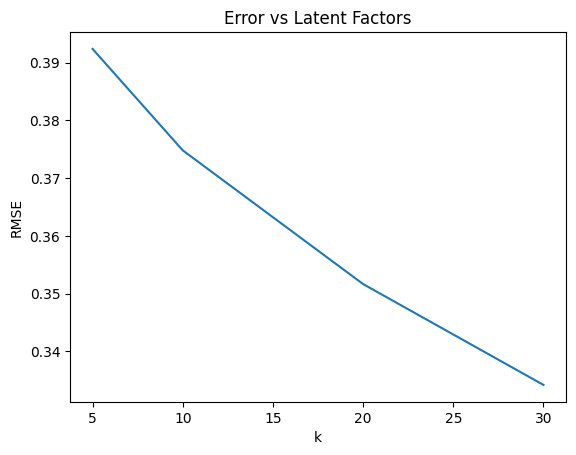

In [5]:
ks = [5,10,20,30]
rmse_list = []

for k in ks:
    U, sigma, Vt = svds(matrix_demeaned, k=k)
    sigma = np.diag(sigma)
    pred = np.dot(np.dot(U, sigma), Vt) + user_mean.reshape(-1,1)

    rmse = np.sqrt(mean_squared_error(matrix, pred))
    rmse_list.append(rmse)

plt.plot(ks, rmse_list)
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()

In [6]:
U, sigma, Vt = svds(matrix_demeaned, k=20)
sigma = np.diag(sigma)
svd_pred = np.dot(np.dot(U, sigma), Vt) + user_mean.reshape(-1,1)

In [7]:
rmse = np.sqrt(mean_squared_error(matrix, svd_pred))
mae = mean_absolute_error(matrix, svd_pred)
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.3516452144212808
MAE: 0.09997831710793079


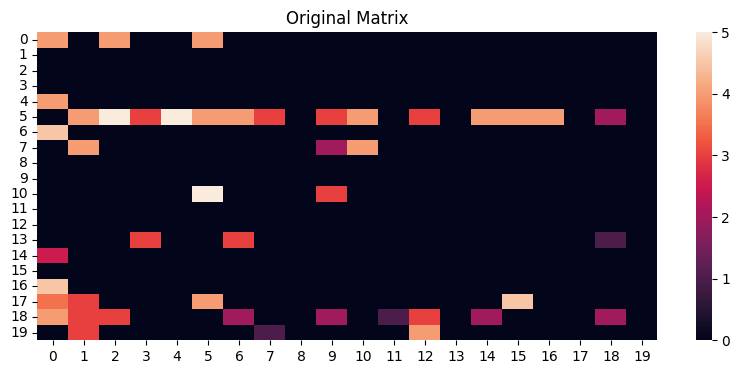

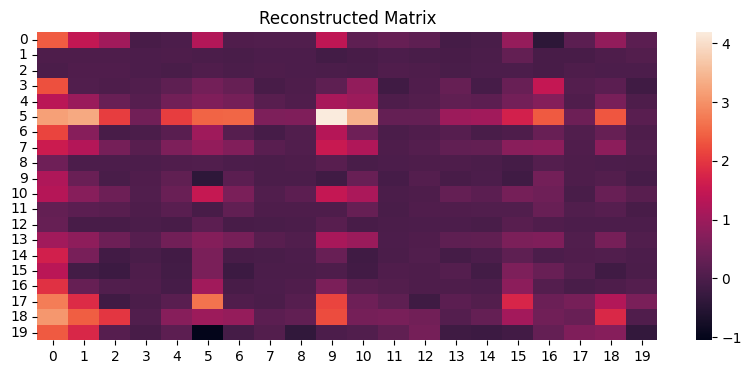

In [8]:
plt.figure(figsize=(10,4))
sns.heatmap(matrix[:20,:20])
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(10,4))
sns.heatmap(svd_pred[:20,:20])
plt.title("Reconstructed Matrix")
plt.show()

In [9]:
user_id = 1
user_ratings = svd_pred[user_id-1]
top_items = np.argsort(user_ratings)[-5:]
print("Top 5 Recommendations:", top_items)

Top 5 Recommendations: [1502 1938  910  224  897]
